# 02 · Ingestion and the medallion layers

The left edge of the architecture: getting public data into **bronze** without breaking anything, and
turning it into **silver** that everything downstream can trust. You'll call the same clients the
pipeline notebooks use (`src/soda_client.py`, `src/open_meteo.py`, `src/area_wiki.py`) against the
live APIs, and see the quirks that shaped the design.

Pipeline notebooks: `01`/`01b` (history), `02`-`02d` (nightly pulls), `03` (silver).

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent   # run from the repo root or tutorials/
sys.path[:0] = [str(ROOT), str(ROOT / "tutorials")]

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import _data
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
                     "grid.color": "#e1e0d9", "axes.prop_cycle": plt.cycler(color=["#2a78d6", "#eb6834", "#1baf7a", "#898781"])})
pd.set_option("display.width", 160, "display.max_columns", 30)
print("data from:", _data.source())

import json
from datetime import date, timedelta

from src.soda_client import CRIMES_DATASET_ID, SERVICE_REQUESTS_DATASET_ID, SocrataClient

client = SocrataClient()        # no key needed; a key (SOCRATA_API_KEY_ID/SECRET) only lifts throttling

data from: local exports


## One client for the city's portal

Every portal dataset (crimes, 311, street and park permits) speaks the same SODA API, so one small client
covers them all. Filters and aggregation run **on the server** through SoQL clauses (`$where`,
`$select`, `$group`), so a nightly pull asks only for what's new, and these tutorials can ask for
counts instead of millions of rows.

In [2]:
print(f"crimes on the portal: {client.count(CRIMES_DATASET_ID):,}")
print(f"311 requests:         {client.count(SERVICE_REQUESTS_DATASET_ID):,}")
row = next(client.get_crimes(limit=1, where="arrest IS NOT NULL"))
print({k: row[k] for k in ("id", "date", "primary_type", "arrest", "domestic", "community_area")})
pd.Series({k: type(v).__name__ for k, v in row.items()}, name="JSON type").to_frame().T

crimes on the portal: 8,650,997


311 requests:         14,756,136


{'id': '14339976', 'date': '2026-09-26T00:00:00.000', 'primary_type': 'BURGLARY', 'arrest': False, 'domestic': False, 'community_area': '24'}


,id,case_number,date,block,iucr,primary_type,description,location_description,arrest,domestic,beat,district,ward,community_area,fbi_code,x_coordinate,y_coordinate,year,updated_on,latitude,longitude,location
JSON type,str,str,str,str,str,str,str,str,bool,bool,str,str,str,str,str,str,str,str,str,str,str,dict


## Why bronze is all strings

Look at the JSON types: almost everything arrives as a string, but `arrest` and `domestic` are real
booleans, and (below) 311's `location` is a nested object that only appears on some rows. Two loaders
write each bronze table: the bulk CSV export (`01`) and the JSON API (`02`). If Spark inferred types per
batch, a batch with a boolean or a nested `location` would produce a column type Delta can't merge into
the existing table, and the nightly append would fail.

So bronze keeps every SODA column as a string (`src/spark_bronze_utils.write_rows_in_chunks`), drops
nested fields nothing downstream reads, and leaves typing to silver. The bulk loader also rewrites the
CSV's `MM/dd/yyyy hh:mm:ss a` dates into the API's ISO format, because the nightly watermark is
`max(date)` *as a string*, which only sorts correctly in ISO.

In [3]:
sr = next(client.get_service_requests(limit=1, where="location IS NOT NULL"))
print("311 location:", type(sr["location"]).__name__, json.dumps(sr["location"])[:120])
print("crime date:  ", row["date"], "(ISO, sorts as a string)")

311 location: dict {"latitude": "41.759888137817", "longitude": "-87.635752660966", "human_address": "{\"address\": \"\", \"city\": \"\", \
crime date:   2026-09-26T00:00:00.000 (ISO, sorts as a string)


## Watermarks: pull only what's new

`02_bronze_incremental` asks the portal for rows newer than the newest one already in bronze:

In [4]:
src = (ROOT / "notebooks/02_bronze_incremental.py").read_text()
print("\n".join(l for l in src.splitlines() if not l.startswith("#") and ("max(" in l or l.startswith("where ="))))

max_date = spark.table(CRIMES_TABLE).selectExpr("max(date) as m").collect()[0]["m"]
where = f"date > '{max_date}'"
max_created = spark.table(SR_TABLE).selectExpr("max(created_date) as m").collect()[0]["m"]
where = f"created_date > '{max_created}'"


One accepted limitation follows: crimes are watermarked on the *offense* date, so a record corrected
weeks later (an arrest added, an area fixed) is never re-fetched. A full fix would re-sync on
`updated_on` and MERGE.

## The newest day is a stub

The crime feed runs about a week behind, and its newest day arrives nearly empty. Here's the last two
months, citywide, straight from the portal:

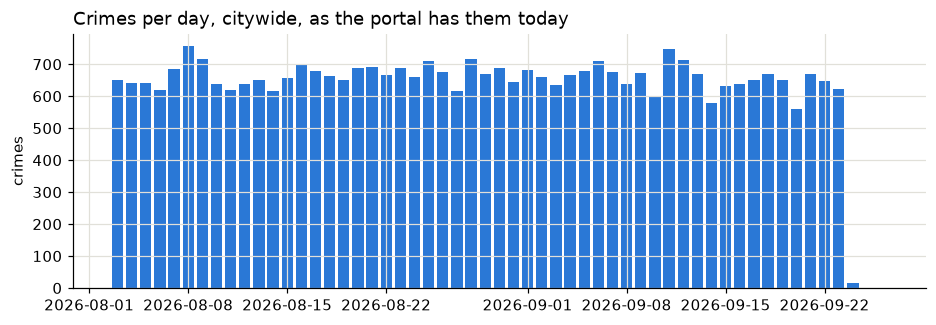

,day,n
49,2026-09-21,669
50,2026-09-22,647
51,2026-09-23,624
52,2026-09-24,16
53,2026-09-26,1


In [5]:
daily = _data.crime_daily_citywide(60)
fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(pd.to_datetime(daily["day"]), daily["n"], width=0.8)
ax.set_title("Crimes per day, citywide, as the portal has them today", loc="left")
ax.set_ylabel("crimes")
plt.show()
daily.tail(5)

Treat that stub as a real day and every "last 30 days" window comes up a day short, and the current
month's projection reads low. So notebook `04` defines the **last full day**: the newest day with at least
half the median count of the 28 days before it. Here's the same rule:

In [6]:
def last_full_day(daily: pd.DataFrame, share: float = 0.5) -> date:
    counts = dict(zip(daily["day"], daily["n"]))
    day = max(counts)
    while True:
        prior = sorted(counts.get(day - timedelta(days=i), 0) for i in range(1, 29))
        if counts.get(day, 0) >= share * prior[len(prior) // 2]:
            return day
        day -= timedelta(days=1)

full = last_full_day(daily)
naive = daily["day"].max()
window = lambda end: daily[(daily["day"] > end - timedelta(days=30)) & (daily["day"] <= end)]["n"].sum()
print(f"newest day in the feed: {naive}, last full day: {full}")
print(f"30 days ending on the newest day: {window(naive):,}; ending on the last full day: {window(full):,}")

newest day in the feed: 2026-09-26, last full day: 2026-09-23
30 days ending on the newest day: 17,804; ending on the last full day: 19,788


Notebook `04` takes the **earlier** of crime's and 311's last full days as one shared as-of date and cuts
everything there, so every window and the partial-month projection cover the same days.

## Silver: types, validity, duplicates

`03_silver_tables` is where bronze becomes usable:
- types the columns downstream code uses (timestamps, booleans, ints, coordinates);
- drops rows with no usable community area (null, or the portal's `0`);
- deduplicates: one row per crime `id` (the latest `updated_on`) and per 311 `sr_number`, since
  append-only bronze can repeat rows;
- drops 311 requests the city itself flags as duplicates (ten people reporting one pothole), which
  would otherwise inflate the leading-indicator counts.

How much does that last rule matter?

In [7]:
since = (date.today() - timedelta(days=30)).isoformat()
total = client.count(SERVICE_REQUESTS_DATASET_ID, where=f"created_date >= '{since}'")
dupes = client.count(SERVICE_REQUESTS_DATASET_ID, where=f"created_date >= '{since}' AND duplicate = true")
print(f"last 30 days: {total:,} requests, {dupes:,} flagged duplicate ({dupes / total:.0%})")

last 30 days: 182,383 requests, 6,791 flagged duplicate (4%)


The deduplication itself is a window function in Spark: partition by the key, order by the
modification time, keep row 1. In pandas it looks like this:

In [8]:
bronze = pd.DataFrame({"id": [1, 1, 2, 3, 3, 3],
                       "updated_on": pd.to_datetime(["2026-01-02", "2026-02-01", "2026-01-05", "2026-01-01",
                                                     "2026-03-01", "2026-02-01"]),
                       "arrest": ["false", "true", "false", "false", "true", "false"]})
silver = bronze.sort_values("updated_on", ascending=False).drop_duplicates("id").sort_values("id")
silver.assign(arrest=silver["arrest"] == "true")

,id,updated_on,arrest
1,1,2026-02-01,True
2,2,2026-01-05,False
4,3,2026-03-01,True


## The other sources

The same pattern repeats for every source: a small client in `src/`, parsers that are shared by the
one-time seed (`01c`, from raw responses uploaded once) and the nightly pull, so a seeded row and a
pulled row always mean the same thing.

**Weather** (`02b`, Open-Meteo, keyless): the observed archive, plus each day's forecast stored with
its issue date. That growing archive of what the forecast *said* is what lets the outlook's backtest
use forecasts that were really issued (tutorial 05).

In [9]:
from src import open_meteo as om

today = date.today()
fc = pd.DataFrame(om.parse_forecast(om.fetch_forecast(om.TEMP_MODEL), om.TEMP_MODEL, today))
fc.head(8)

,target_day,issue_date,lead_days,model,t_mean,precip
0,2026-10-02,2026-10-02,0,gfs_seamless,14.0,1.1
1,2026-10-03,2026-10-02,1,gfs_seamless,12.8,0.0
2,2026-10-04,2026-10-02,2,gfs_seamless,16.6,0.0
3,2026-10-05,2026-10-02,3,gfs_seamless,15.2,0.0
4,2026-10-06,2026-10-02,4,gfs_seamless,14.7,0.0
5,2026-10-07,2026-10-02,5,gfs_seamless,18.0,0.0
6,2026-10-08,2026-10-02,6,gfs_seamless,19.8,3.0
7,2026-10-09,2026-10-02,7,gfs_seamless,16.3,0.0


**Wikipedia** (`02d`, `03c`): the 77 area articles, re-fetched only when their revision id changes,
then cut into passages for the agent's vector search index. Passages never cross a section, each one
names its area and section (so a short one still says where it's from), and each keeps its article URL
for attribution.

In [10]:
from src import area_wiki as aw
from src.community_areas import AREA_NAMES

titles = aw.fetch_area_titles()
article = aw.fetch_article(titles[24]["title"])
chunks = aw.chunk_article(24, AREA_NAMES[24], article["extract"], article["page_url"], article["revid"])
print(f"{len(titles)} areas listed; {article['title']}: {len(article['extract'].split()):,} words -> {len(chunks)} passages")
print([c["section"] for c in chunks][:10])
print(chunks[1]["content"][:250], "...")
print("source:", article["page_url"], "(CC BY-SA 4.0)")

77 areas listed; West Town, Chicago: 4,458 words -> 21 passages
['Overview', 'History', 'History', 'History', 'Neighborhoods > Pulaski Park', 'Neighborhoods > Pulaski Park', 'Neighborhoods > Wicker Park', 'Neighborhoods > Wicker Park', 'Neighborhoods > Wicker Park', 'Neighborhoods > Ukrainian Village']
West Town (Chicago community area 24) - History

Polish immigration into the area accelerated during and after World War II when as many as 150,000 Poles are estimated to have arrived between 1939 and 1959 as displaced persons. Like the Ukrainians in ...
source: https://en.wikipedia.org/wiki/West_Town,_Chicago (CC BY-SA 4.0)


## Takeaways

- **Bulk first, then incremental.** History comes from a bulk export or a resumable month-by-month
  backfill; nightly pulls only ask for what's past the watermark.
- **Three write modes** (`src/spark_bronze_utils.py`): batched appends for the big SODA datasets, MERGE on
  a key for small keyed pulls, and atomic `replaceWhere` windows for sources whose past rows change
  (permits are re-pulled for the last 180 days).
- **Bronze absorbs the sources' quirks; silver makes promises.** Everything downstream reads silver.

Next: [03 · Trends and normals](03_trends_and_normals.ipynb), where silver becomes the numbers on the map.